# Active users analysis with links.

In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [11]:
# Load the dataset
# import datasets
df = pd.read_json("../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

In [12]:
# Define a function to extract messages with links 
def contains_link(text):
    """Return True if the text contains a URL."""
    if not isinstance(text, str):
        return False
    # Simple regex to match common URL patterns
    url_pattern = re.compile(
        r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+'
        r'|www\.[a-zA-Z0-9\-]+(?:\.[a-zA-Z]{2,})+'
    )
    return bool(url_pattern.search(text))

## Check number of messages with links per channel

In [13]:
# Check number of messages containing links per channel
df['has_link'] = df['message'].apply(contains_link)
link_counts = df.groupby('topic_name')['has_link'].sum().reset_index(name='link_count')
# Display the link counts per channel
print(link_counts)

                                           topic_name  link_count
0   Asis. Grupos Vulnerables (Maternidad , Infanci...          10
1                  Asistencia Informática/Soporte EAT         124
2                         Asistencia Jurídica/Seguros          95
3   Asistencia Técnica y Maquinaria (mecánica, fon...          56
4        Asistencia a Voluntarios (Comida y Acogida))         139
5                Asistencia animales compañia y otros         115
6                                   Ayuda de Empresas          50
7   Bienvenid@s a la Red de Voluntari@s (leed prim...         230
8                                   Discusión general          19
9             Grupos de Acción Voluntarios en Terreno         127
10  Investigación Ciudadana: Responsabilidades Pol...         428
11    Logística Interna Valencia(puntos de recepción)         124
12                         Material Video/Fotográfico         289
13               Mensajes de Ayuda (Ofrezco/Necesito)          28
14      Tr

In [14]:
# Percentage of messages containing links per channel and number of messages per channel
link_counts_current = (
    df.groupby('topic_name')['has_link']
    .sum()
    .reset_index(name='link_count')
)
message_counts = (
    df.groupby('topic_name')['message']
    .count()
    .reset_index(name='message_count')
)

channel_link_stats = link_counts_current.merge(
    message_counts,
    on='topic_name',
    how='inner',
    validate='one_to_one'
 )
channel_link_stats['link_percentage'] = (
    channel_link_stats['link_count'] / channel_link_stats['message_count']
 ) * 100
channel_link_stats['total_messages'] = channel_link_stats['message_count']

print(channel_link_stats[['topic_name', 'link_percentage', 'total_messages']])

                                           topic_name  link_percentage  \
0   Asis. Grupos Vulnerables (Maternidad , Infanci...         6.944444   
1                  Asistencia Informática/Soporte EAT         6.313646   
2                         Asistencia Jurídica/Seguros        11.599512   
3   Asistencia Técnica y Maquinaria (mecánica, fon...        11.475410   
4        Asistencia a Voluntarios (Comida y Acogida))        11.951849   
5                Asistencia animales compañia y otros        11.132623   
6                                   Ayuda de Empresas        16.666667   
7   Bienvenid@s a la Red de Voluntari@s (leed prim...         8.053221   
8                                   Discusión general         7.421875   
9             Grupos de Acción Voluntarios en Terreno        12.072243   
10  Investigación Ciudadana: Responsabilidades Pol...        15.451264   
11    Logística Interna Valencia(puntos de recepción)         9.487376   
12                         Material Vi

                                           topic_name  link_percentage  \
0                                     Webs Esenciales        91.666667   
1   Voluntarios de fuera de Valencia (Madrid, Cata...        27.450980   
2                          Material Video/Fotográfico        24.700855   
3                                   Ayuda de Empresas        16.666667   
4                Mensajes de Ayuda (Ofrezco/Necesito)        16.000000   
5   Investigación Ciudadana: Responsabilidades Pol...        15.451264   
6             Grupos de Acción Voluntarios en Terreno        12.072243   
7        Asistencia a Voluntarios (Comida y Acogida))        11.951849   
8   Viviendas Edificación , Muebles y Acondicionam...        11.682243   
9                         Asistencia Jurídica/Seguros        11.599512   
10  Asistencia Técnica y Maquinaria (mecánica, fon...        11.475410   
11               Asistencia animales compañia y otros        11.132623   
12    Logística Interna Valencia(punto

C:\Users\Usuario\AppData\Local\Temp\ipykernel_118472\2748123350.py:20: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


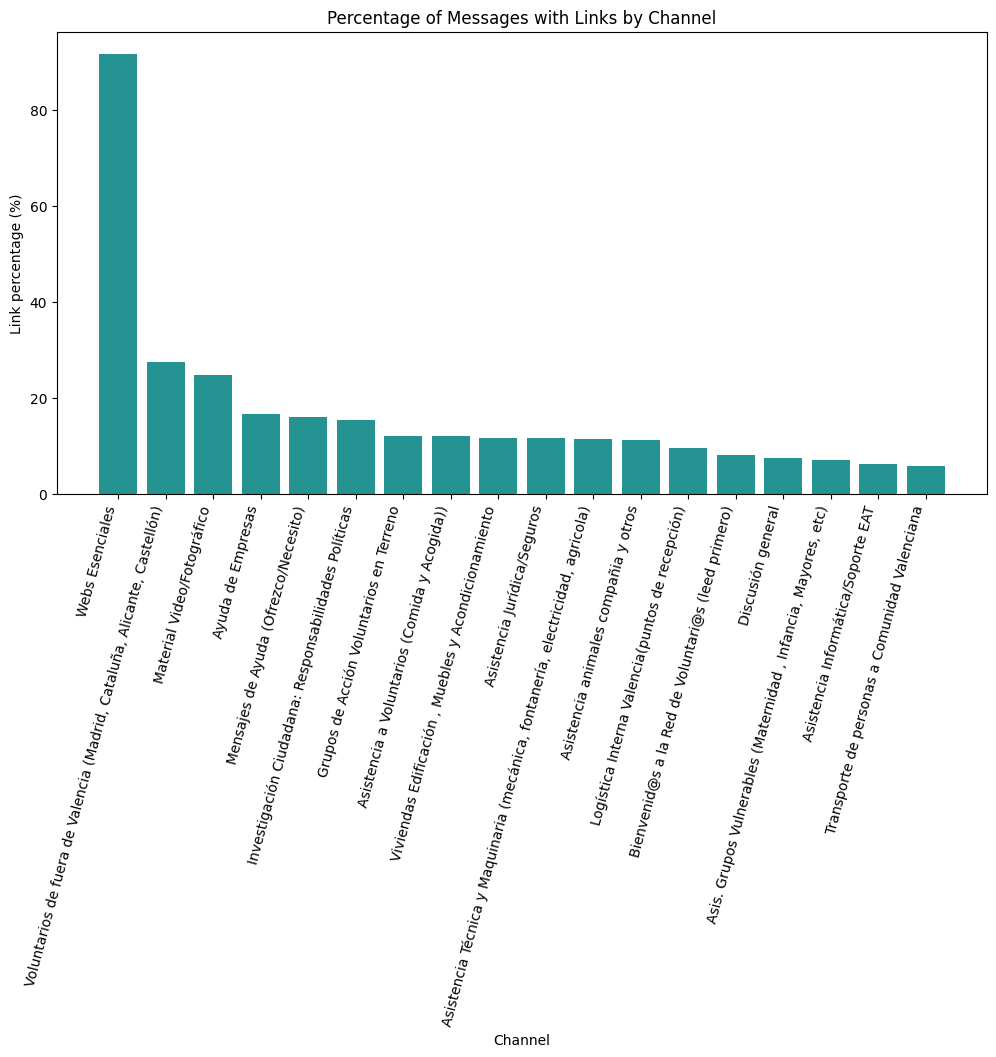

In [15]:
# Sort channels by link percentage and visualize
channel_link_stats_sorted = channel_link_stats.sort_values(
    by=['link_percentage', 'total_messages'],
    ascending=[False, False]
).reset_index(drop=True)

print(channel_link_stats_sorted[['topic_name', 'link_percentage', 'total_messages']])

plt.figure(figsize=(12, 6))
plt.bar(
    channel_link_stats_sorted['topic_name'],
    channel_link_stats_sorted['link_percentage'],
    color='teal',
    alpha=0.85
)
plt.title('Percentage of Messages with Links by Channel')
plt.xlabel('Channel')
plt.ylabel('Link percentage (%)')
plt.xticks(rotation=75, ha='right')
plt.tight_layout()
plt.show()

In [17]:
df_links.head()

,date,links,platform,username,sender_id,sender_username,sender_name,sender_type,count,username_count,political,type,political_orientation,fake_information,is_forwarded,fwd_from_channel_id,fwd_from_channel_name
0,2024-10-30T15:00:42+00:00,https://www.instagram.com/victimas_dana_vlc/pr...,instagram,victimas_dana_vlc,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,user,1.0,1.0,NaN,extracted_link,NaN,NaN,NaN,NaN,NaN
1,2024-10-30T19:15:18+00:00,https://www.google.com/maps/d/viewer?mid=1WbP4...,google,google,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,user,1.0,78.0,NaN,extracted_link,NaN,NaN,NaN,NaN,NaN
2,2024-10-30T19:58:22+00:00,https://g.co/kgs/y7dLSiz,other,g,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,user,1.0,18.0,non-political,extracted_link,NaN,NaN,NaN,NaN,NaN
3,2024-10-30T19:59:30+00:00,https://g.co/kgs/q6e1mmU,other,g,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,user,1.0,18.0,non-political,extracted_link,NaN,NaN,NaN,NaN,NaN
4,2024-10-30T20:00:34+00:00,https://g.co/kgs/VDFK7XY,other,g,1110241832,Manuel_deRonde,Manuel DeRonde - Coordinador Civil 🫱🏻‍🫲🏼,user,1.0,18.0,non-political,extracted_link,NaN,NaN,NaN,NaN,NaN


In [20]:
# Number of users sending links
users_with_links = df_links['sender_id'].nunique()
print(f'Number of unique users who sent messages with links: {users_with_links}')
#Total number of users
total_users = df['sender_id'].nunique()
print(f'Total number of unique users: {total_users}')
# Percentage of users sending links
link_senders_percentage = (users_with_links / total_users) * 100
print(f'Percentage of users who sent messages with links: {link_senders_percentage:.2f}%')  

Number of unique users who sent messages with links: 447
Total number of unique users: 2539
Percentage of users who sent messages with links: 17.61%


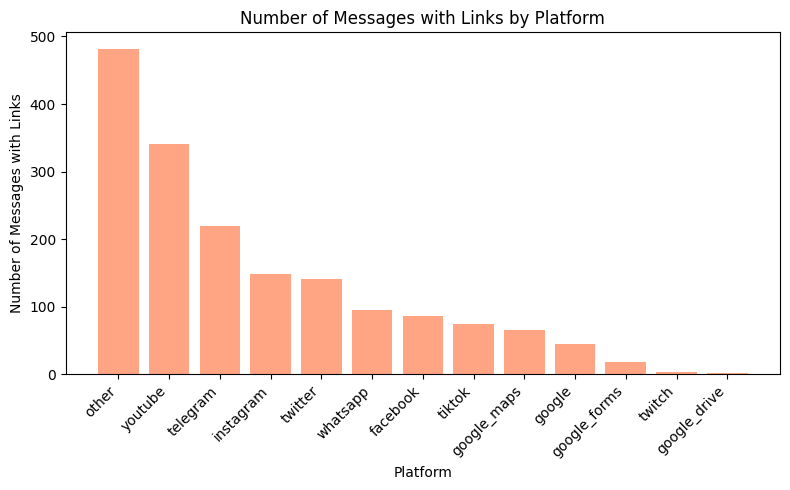

In [24]:
# Plot number of messages with links per platform
platform_link_counts = (
    df_links['platform']
    .dropna()
    .value_counts()
    .rename_axis('platform')
    .reset_index(name='link_messages')
)

plt.figure(figsize=(8, 5))
plt.bar(
    platform_link_counts['platform'],
    platform_link_counts['link_messages'],
    color='coral',
    alpha=0.7
 )
plt.title('Number of Messages with Links by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Messages with Links')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [25]:
df_links['political'].unique()

array([nan, 'non-political', 'political'], dtype=object)

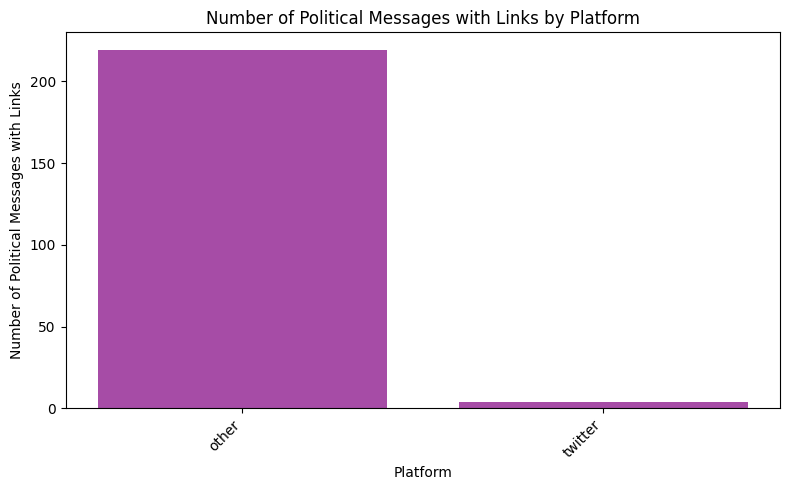

In [27]:
# Number of messages containing links per platform if they are political
political_link_counts = (
    df_links[df_links['political'] == 'political']['platform']
    .dropna()
    .value_counts()
    .rename_axis('platform')
    .reset_index(name='political_link_messages')
)
# Plot number of political messages with links per platform
plt.figure(figsize=(8, 5))
plt.bar(
    political_link_counts['platform'],
    political_link_counts['political_link_messages'],
    color='purple',
    alpha=0.7
 )
plt.title('Number of Political Messages with Links by Platform')
plt.xlabel('Platform')
plt.ylabel('Number of Political Messages with Links')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [28]:
df_links['political_orientation'].unique()

array([nan, 'center-right', 'unknown', 'right', 'center', 'far-right',
       'center-left', 'anti-establisment', 'debunker', 'left'],
      dtype=object)

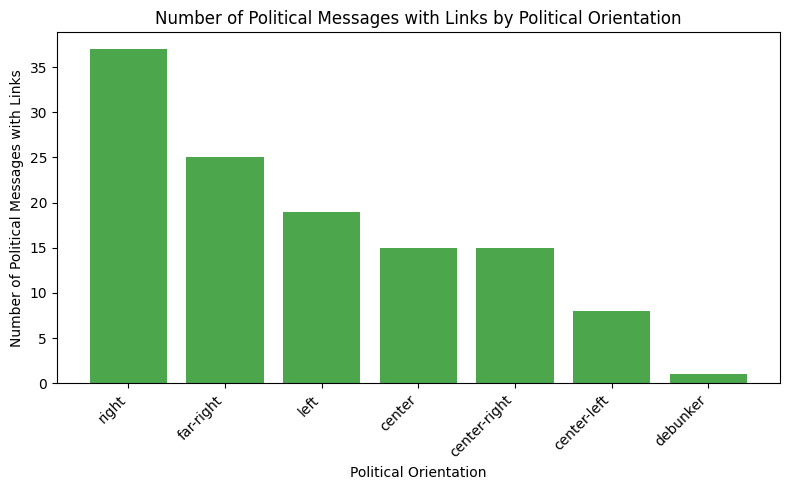

In [29]:
# Plot number of political messages with links per political orientation
orientation_link_counts = (
    df_links[df_links['political'] == 'political']['political_orientation']
    .dropna()
    .value_counts()
    .rename_axis('political_orientation')
    .reset_index(name='political_link_messages')
)
plt.figure(figsize=(8, 5))
plt.bar(
    orientation_link_counts['political_orientation'],
    orientation_link_counts['political_link_messages'],
    color='green',
    alpha=0.7
 )
plt.title('Number of Political Messages with Links by Political Orientation')
plt.xlabel('Political Orientation')
plt.ylabel('Number of Political Messages with Links')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [30]:
df_links['fake_information'].unique()

array([nan, 'unknown', 'high', 'Mixed', 'low', 'True', 'mostly factual',
       'very high', 'mixed', 'very-low'], dtype=object)

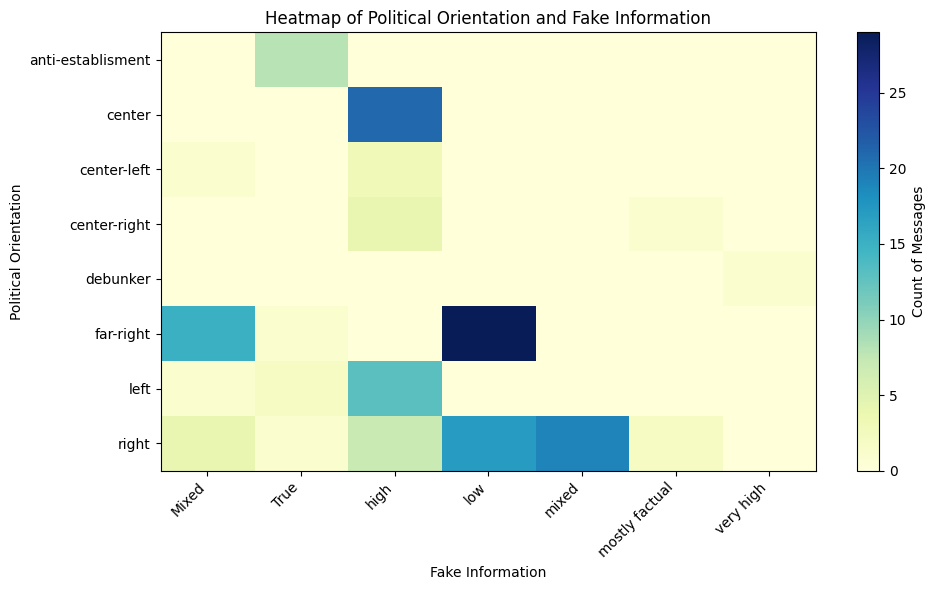

In [33]:
#plot heatmap of political orientation and fake information (without unknown)
heatmap_data = pd.crosstab(
    df_links['political_orientation'].dropna(),
    df_links['fake_information'].dropna()
)
# Remove 'unknown' category from heatmap data
if 'unknown' in heatmap_data.columns:
    heatmap_data = heatmap_data.drop(columns='unknown') 
    heatmap_data = heatmap_data.drop(index='unknown')
plt.figure(figsize=(10, 6))
plt.imshow(heatmap_data, cmap='YlGnBu', aspect='auto')
plt.title('Heatmap of Political Orientation and Fake Information')
plt.xlabel('Fake Information')
plt.ylabel('Political Orientation')
plt.colorbar(label='Count of Messages')
plt.xticks(ticks=np.arange(len(heatmap_data.columns)), labels=heatmap_data.columns, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(heatmap_data.index)), labels=heatmap_data.index, rotation=0)
plt.tight_layout()
plt.show()  

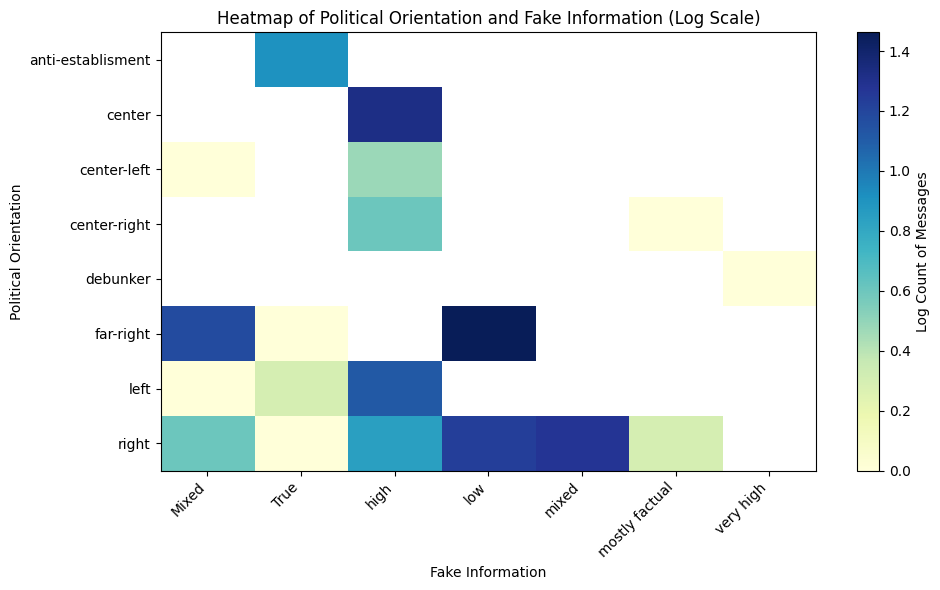

In [34]:
#Same heatmap but in logarithmic scale
heatmap_data_log = heatmap_data.replace(0, np.nan).apply(np.log10)
plt.figure(figsize=(10, 6))
plt.imshow(heatmap_data_log, cmap='YlGnBu', aspect='auto')
plt.title('Heatmap of Political Orientation and Fake Information (Log Scale)')
plt.xlabel('Fake Information')
plt.ylabel('Political Orientation')
plt.colorbar(label='Log Count of Messages')
plt.xticks(ticks=np.arange(len(heatmap_data_log.columns)), labels=heatmap_data_log.columns, rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(heatmap_data_log.index)), labels=heatmap_data_log.index, rotation=0)
plt.tight_layout()
plt.show()
